In [1]:
from soma import aims
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import multiprocessing
from multiprocessing import Pool
multiprocessing.cpu_count()

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


32

## To count the non zero values in the sulci skeletons

In [82]:
side = 'L'
skeleton_type = 'raw'

list_skeleton_type = ['raw', '2mm']
assert skeleton_type in list_skeleton_type, "skeleton_type not in list_skeleton_type \n Must be 'raw' or '2mm'"

list_subjects = pd.read_csv('/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/participants_sex_age.csv')
list_subjects = list_subjects['Subject'].to_list()

In [83]:
def get_skeleton_size(subject_id):
    """ 
    Count the number of non negative voxels for a subject, for a given hemisphere.

    Args:
        subject_id (str): for instance 'sub-3459925'
        skeleton_type (str): must be 'raw' or '2mm'
        side (str): must be 'L' or 'R'

    Return:
         subject_id, skeleton_size
    """
    if skeleton_type == 'raw':
        # To work with the raw skeleton on the TGCC
        #mm_skeleton_path = f'/home/ad279118/tmp/{subject_id}/ses-2/anat/t1mri/default_acquisition/default_analysis/segmentation'
        #skeleton_path = f"{mm_skeleton_path}/{side}skeleton_{subject_id}.nii.gz"
        
        # To work with the raw skeleton on the /neurospin/dico
        mm_skeleton_path = f'/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/skeletons/raw/{side}'
        skeleton_path = f"{mm_skeleton_path}/{side}skeleton_generated_{subject_id}.nii.gz"

    elif skeleton_type == '2mm':
        mm_skeleton_path = f'/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/skeletons/2mm/{side}'
        skeleton_path = f"{mm_skeleton_path}/{side}resampled_skeleton_{subject_id}.nii.gz"

    else:
        raise "skeleton_type not in list_skeleton_type \n Must be 'raw' or '2mm'"

    if os.path.isfile(skeleton_path):
        skeleton = aims.read(skeleton_path)
        skeleton_size = np.count_nonzero((skeleton.np > 0))

        return subject_id, skeleton_size

    else:
        print(f'{skeleton_path} not found')
        return 0, 0

In [85]:
list_skeleton_size = []
valid_subjects = []


with Pool(processes=multiprocessing.cpu_count()) as pool:
  for subject_id, skeleton_size in pool.imap(get_skeleton_size, list_subjects):
    if skeleton_size!=0:
      list_skeleton_size.append(skeleton_size)
      valid_subjects.append(subject_id)
  
print(len(valid_subjects), len(list_skeleton_size))
df_skeleton = pd.DataFrame({"ID": valid_subjects, "skeleton_size": list_skeleton_size})

/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/skeletons/raw/L/Lskeleton_generated_sub-1006457.nii.gz not found
/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/skeletons/raw/L/Lskeleton_generated_sub-3986524.nii.gz not found
/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/skeletons/raw/L/Lskeleton_generated_sub-4092942.nii.gz not found
/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/skeletons/raw/L/Lskeleton_generated_sub-4079377.nii.gz not found
/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/skeletons/raw/L/Lskeleton_generated_sub-1007961.nii.gz not found
/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/skeletons/raw/L/Lskeleton_generated_sub-2333935.nii.gz not found
/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/skeletons/raw/L/Lskeleton_generated_sub-2204715.nii.gz not found
/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/skeletons/raw/L/Lskeleton_generated_sub-4

In [86]:
#df_skeleton.to_csv(f'/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/skeletons/{side}raw_skeleton_size.csv', index=False)

## Plot the distribution of non zero voxels

In [39]:
side = "R"
skeleton_type = "resampled" # 'raw', 'resampled'

df_skeleton = pd.read_csv(f'/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/skeletons/{side}{skeleton_type}_skeleton_size.csv')

In [40]:
# QC method ?

percentiles = np.percentile(df_skeleton[['skeleton_size']], 90)

print('Threshold for the 90 Percentile:')
print(percentiles)
print(len(df_skeleton[df_skeleton['skeleton_size'] > 1.1*percentiles].ID.to_list()))
df_skeleton[df_skeleton['skeleton_size'] > 1.1*percentiles].ID.to_list()

Threshold for the 90 Percentile:
11496.0
53


['sub-1006217',
 'sub-2955789',
 'sub-2122485',
 'sub-4626716',
 'sub-2481728',
 'sub-2955962',
 'sub-4426552',
 'sub-3757741',
 'sub-3899233',
 'sub-1516814',
 'sub-3044755',
 'sub-5417598',
 'sub-5866106',
 'sub-3376075',
 'sub-4845802',
 'sub-2632685',
 'sub-4856794',
 'sub-3628545',
 'sub-5543692',
 'sub-2159521',
 'sub-2632623',
 'sub-1736237',
 'sub-2336283',
 'sub-5472164',
 'sub-3396940',
 'sub-2408225',
 'sub-4645343',
 'sub-1219530',
 'sub-3577510',
 'sub-5275233',
 'sub-4402019',
 'sub-2231397',
 'sub-3462799',
 'sub-2718550',
 'sub-2224058',
 'sub-4519962',
 'sub-4961802',
 'sub-4656699',
 'sub-5890726',
 'sub-2146417',
 'sub-1815181',
 'sub-2169184',
 'sub-4398224',
 'sub-4886645',
 'sub-3575061',
 'sub-5098521',
 'sub-5894417',
 'sub-3459925',
 'sub-5643477',
 'sub-2126502',
 'sub-4783825',
 'sub-2359872',
 'sub-3492301']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


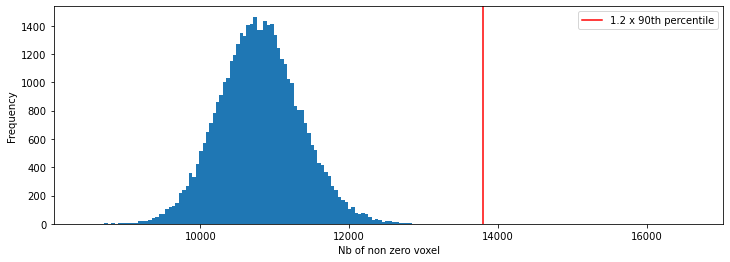

In [41]:
%matplotlib inline
plt.figure(figsize=(12,4))
plt.hist(df_skeleton["skeleton_size"], bins=180)
plt.axvline(x=1.2*percentiles, color='r', label="1.2 x 90th percentile")
plt.xlabel('Nb of non zero voxel')
plt.ylabel('Frequency')
plt.legend()
plt.savefig(f'/volatile/ad279118/Imaging_Genetics_2025/Figures_Report/{side}{skeleton_type}_skeleton_size.eps', format='eps')
plt.show()

In [9]:
df_outliers = df_skeleton[df_skeleton["skeleton_size"]>13000]
df_outliers.sort_values(by="skeleton_size", ).ID.to_list()[:10]

['sub-3459925',
 'sub-2224058',
 'sub-2718550',
 'sub-5543692',
 'sub-1331493',
 'sub-3871152',
 'sub-3139301',
 'sub-5330725',
 'sub-4211276',
 'sub-5099206']

## Use the brain volume as another metric to assess the quality of the data

In [125]:
df_raw_skeleton=pd.read_csv('/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/skeletons/Rraw_skeleton_size.csv')

In [126]:
df_brain_volume = pd.read_csv('/volatile/ad279118/UKB/QC/brain_segmentation_volume.csv', header=None)
merge = pd.merge(df_raw_skeleton, df_brain_volume, left_on='ID', right_on=0, how='inner')
merge = merge.drop(0, axis=1)
merge = merge.rename(columns={1:"brain_volume"})
merge["QC_metric"] = merge.skeleton_size / (merge.brain_volume)**(2/3)

In [127]:
b = (pd.merge(merge.drop(["skeleton_size"], axis=1), df_skeleton, left_on='ID', right_on='ID'))
b[["QC_metric", "skeleton_size"]].corr()


,QC_metric,skeleton_size
QC_metric,1.000000,0.732035
skeleton_size,0.732035,1.000000


Text(0, 0.5, 'Resampled skeleton size')

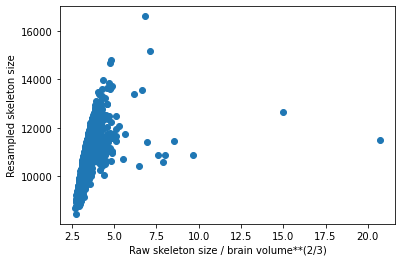

In [128]:
plt.scatter(b["QC_metric"], b["skeleton_size"])
plt.xlabel("Raw skeleton size / brain volume**(2/3)")
plt.ylabel("Resampled skeleton size")

Text(0, 0.5, 'Brain volume')

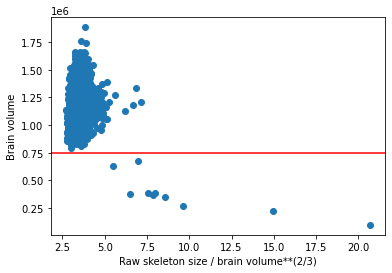

In [142]:
plt.scatter(b["QC_metric"], b["brain_volume"])
plt.axhline(y=0.75e6, color='r', linestyle='-')
plt.xlabel("Raw skeleton size / brain volume**(2/3)")
plt.ylabel("Brain volume")

In [141]:
b[b["brain_volume"] < 0.75e6].ID.to_list()

['sub-3829981',
 'sub-2927441',
 'sub-3044755',
 'sub-1832571',
 'sub-1146029',
 'sub-5001586',
 'sub-1366082',
 'sub-4030844',
 'sub-3675637',
 'sub-5963962']

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


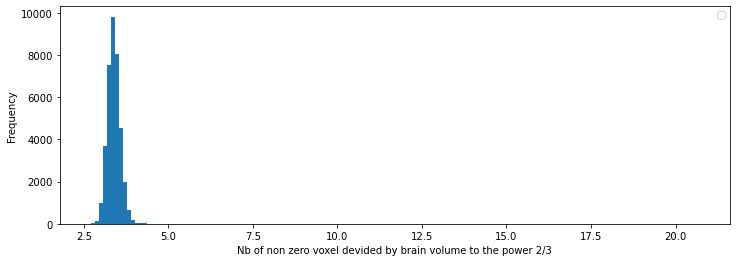

In [144]:
plt.figure(figsize=(12,4))
plt.hist(b["QC_metric"], bins=150)
plt.xlabel('Nb of non zero voxel devided by brain volume to the power 2/3')
plt.ylabel('Frequency')
plt.legend()
#plt.savefig(f'/volatile/ad279118/Imaging_Genetics_2025/Figures_Report/QC_metric.eps', format='eps')
plt.show()

## Based on the hypothesis that a bad image would give diferent results in both hemispheres

We can compare the number of non zero voxels in both hemispheres. 
Would make more sense removing the insula sulcus and the ventricule.

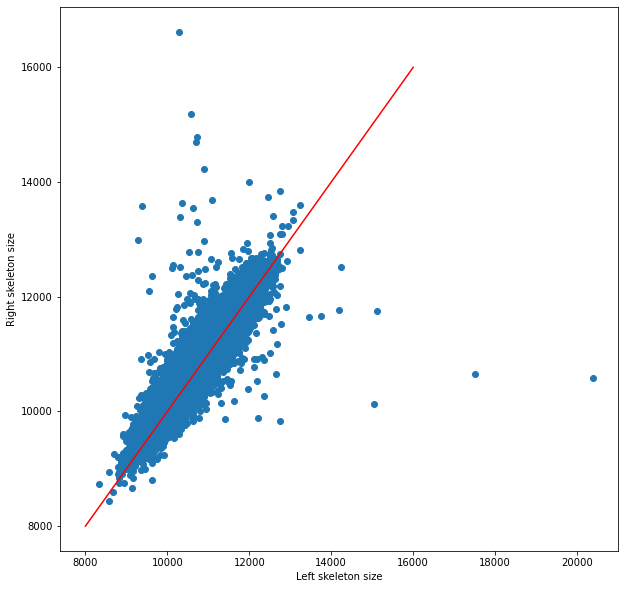

In [42]:
skeleton_type = "resampled" # 'raw', 'resampled'

df_Lskeleton = pd.read_csv(f'/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/skeletons/L{skeleton_type}_skeleton_size.csv')
df_Rskeleton = pd.read_csv(f'/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/skeletons/R{skeleton_type}_skeleton_size.csv')

merge = pd.merge(df_Lskeleton, df_Rskeleton, on='ID', suffixes=('_L', '_R'))
plt.figure(figsize=(10,10))
plt.scatter(merge["skeleton_size_L"], merge["skeleton_size_R"])
plt.plot(np.linspace(8000,16000, 2), np.linspace(8000,16000, 2), color='red')
plt.xlabel("Left skeleton size")
plt.ylabel("Right skeleton size")
plt.show()

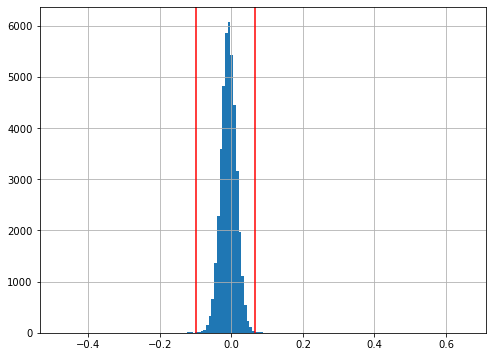

['sub-1467575',
 'sub-5431753',
 'sub-5908463',
 'sub-1209582',
 'sub-3674785',
 'sub-4254296',
 'sub-3008512',
 'sub-4756195',
 'sub-4605080',
 'sub-5033389',
 'sub-3492221',
 'sub-5583089',
 'sub-5758558',
 'sub-2715778',
 'sub-5124493',
 'sub-2820417',
 'sub-2497931',
 'sub-5258364',
 'sub-4259217',
 'sub-2901062']

In [60]:
merge["log ratio"] = np.log(merge.skeleton_size_L / merge.skeleton_size_R)
plt.figure(figsize=(8,6))
merge["log ratio"].hist(bins=150)
plt.axvline(x=-0.097854, color='r', label="threshold")
plt.axvline(x=0.067197, color='r', label="threshold")
plt.show()

merge.sort_values(by="log ratio")["ID"][-60:-40].to_list()

In [59]:
merge.sort_values(by="log ratio")[-60:]

,ID,skeleton_size_L,skeleton_size_R,log ratio
9181,sub-1467575,12479,11668,0.067197
20669,sub-5431753,12154,11362,0.067384
1774,sub-5908463,11041,10318,0.067726
18473,sub-1209582,11893,11103,0.068735
8590,sub-3674785,11078,10337,0.069231
39331,sub-4254296,10896,10164,0.069544
26155,sub-3008512,12651,11789,0.070569
30154,sub-4756195,11638,10840,0.071033
17502,sub-4605080,10612,9882,0.071271
4329,sub-5033389,10651,9908,0.072311
